<a href="https://colab.research.google.com/github/alracey/level4-project/blob/main/piecewise_linear_pytorch_opt_bins_NNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
dtype = torch.float32

Using device: cpu


Define the original function f, the transform itself g, and the transformed function h.

In [3]:
sigma = 0.05

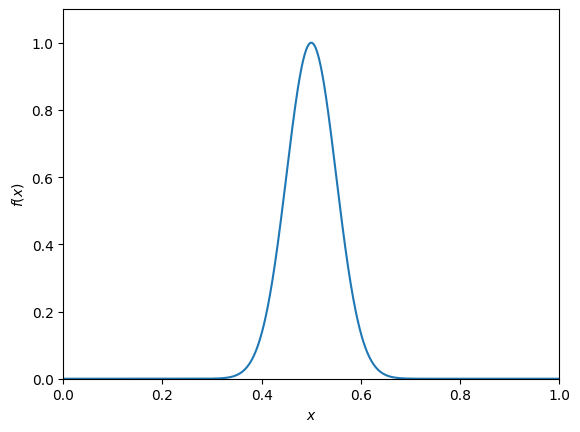

In [4]:
def f(x):
  return torch.exp(-((x-0.5)**2 / (2*(sigma)**2)))

xs = torch.linspace(0, 1, 1000)
f_evals = f(xs)
plt.plot(xs, f_evals)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.xlim(0, 1)
plt.ylim(0, 1.1)
plt.show()

In [5]:
def g(x, params, bins):   #piecewise linear transform with K bins

  device = x.device
  dtype = x.dtype
  K = len(params) + 1


  #cdf heights
  heights = torch.cat([torch.tensor([0.0]), params, torch.tensor([1.0])])

  #find indices
  i_values = torch.bucketize(x, bins, right=False) - 1
  i_values_right = torch.clamp(i_values + 1, max=K)

  #find the correct bin indices i for each x value (old method)
  #i_values = torch.clamp((x * K).long(), max=K-1)

  #compute the edges
  x_left = bins[i_values]
  x_right = bins[i_values_right]
  y_left = heights[i_values]
  y_right = heights[i_values_right]

  #compute the linear mappings for all x

  return y_left + ((y_right - y_left) / (x_right - x_left)) * (x - x_left)


In [6]:
def plot_g(params, bins, display_bins):

  x_plot = torch.rand(1000)
  x_plot = x_plot.sort().values

  g_plot = g(x_plot, params, bins)

  fig, ax = plt.subplots()

  ax.plot(x_plot.cpu(), g_plot.cpu())

  if display_bins == True:
    for b in bins[1:-1]:
      ax.axvline(b.item(), color="gray", alpha=0.6)

  ax.set_xlabel(f"$x$", fontsize=14)
  ax.set_ylabel(f"$g(x)$", fontsize=14)

  ax.set_xlim(0.0, 1.0)
  ax.set_ylim(0.0, 1.0)

  ax.tick_params(axis="both", which="major", direction="in", length=5, labelsize=10)
  ax.tick_params(axis="both", which="minor", direction="in", length=3)
  ax.minorticks_on()

  plt.show()

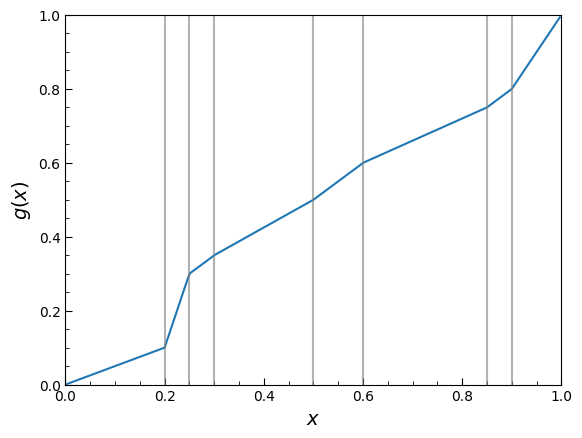

In [7]:
#test plot

test_params = torch.tensor([0.1, 0.3, 0.35, 0.5, 0.6, 0.75, 0.8])
test_bins = torch.tensor([0, 0.2, 0.25, 0.3, 0.5, 0.6, 0.85, 0.9, 1])

plot_g(test_params, test_bins, True)

In [8]:
def h(y, params, bins):
  '''
  Resulting function when the piecewise warp is applied, in accordance with the change of variables formula.
  Integral should be preserved.
  Non-uniform bins permitted.
  '''

  device = y.device
  dtype = y.dtype
  K = len(params) + 1

  #cdf heights
  heights = torch.cat([torch.tensor([0.0]), params, torch.tensor([1.0])])

  #find indices
  j_values = torch.bucketize(y, heights, right=False) - 1
  j_values_right = torch.clamp(j_values + 1, max=K)

  #find the correct indices
  #j_values = torch.clamp((torch.searchsorted(ys, y) - 1), 0, K-1)

  #compute the edges
  x_left = bins[j_values]
  x_right = bins[j_values_right]
  y_left = heights[j_values]
  y_right = heights[j_values_right]

  def g_inv(y):

    return x_left + ((x_right - x_left) / (y_right - y_left)) * (y - y_left)

  jacobians = (x_right - x_left) / (y_right - y_left)

  arg = g_inv(y)

  return f(arg) * jacobians

In [9]:
#plot h

def plot_h(params, bins):

  y_plot = torch.rand(1000)
  y_plot = y_plot.sort().values

  h_plot = h(y_plot, params, bins)

  fig, ax = plt.subplots()

  ax.plot(y_plot.cpu(), h_plot.cpu())

  ax.set_xlabel(f"$y$", fontsize=14)
  ax.set_ylabel(f"$h(y)$", fontsize=14)

  ax.set_xlim(0.0, 1.0)

  ax.tick_params(axis="both", which="major", direction="in", length=5, labelsize=10)
  ax.tick_params(axis="both", which="minor", direction="in", length=3)
  ax.minorticks_on()

  plt.show()

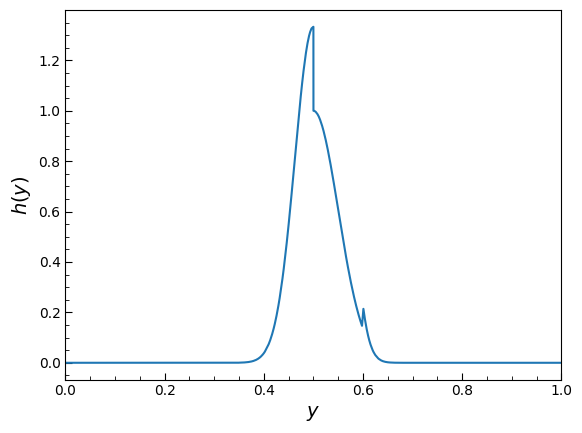

In [10]:
plot_h(test_params, test_bins)

Integral preservation and variance checks

In [11]:
N = 1000000

#reference value: 0.125331

def MC_F(N):
  x = torch.rand(N)
  f_evals = f(x)
  F_est = torch.mean(f_evals)
  alpha_F = torch.std(f_evals) / torch.sqrt(torch.tensor(N))
  return F_est, alpha_F

def MC_H(N, params, bins):
  y = torch.rand(N)
  h_evals = h(y, params, bins)
  H_est = torch.mean(h_evals)
  alpha_H = torch.std(h_evals) / torch.sqrt(torch.tensor(N))
  return H_est, alpha_H


F_est, alpha_F = MC_F(N)
print(f'F estimate = {F_est} ± {alpha_F}')

H_est, alpha_H = MC_H(N, test_params, test_bins)
print(f'H estimate = {H_est} ± {alpha_H}')


F estimate = 0.12496653199195862 ± 0.0002696228330023587
H estimate = 0.12595504522323608 ± 0.00029707676731050014


In [12]:
#check variances are different in general

x_test, y_test = torch.rand(N), torch.rand(N)

f_var = torch.var(f(x_test))

h_for_var = h(y_test, test_params, test_bins)
h_var = torch.var(h_for_var)

print("F variance:", f_var)
print("H variance:", h_var)

F variance: tensor(0.0729)
H variance: tensor(0.0877)


Optimisation via training loop

In [13]:
#neural network for cdf heights V

class flownet_V(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=output_size),
    )

  def forward(self, x):
        return self.linear_layer_stack(x)



#neural network for bin widths W

class flownet_W(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=output_size),
    )

  def forward(self, x):
        return self.linear_layer_stack(x)



In [14]:
#getting to grips with dimensions here
K=8
X = torch.rand(10, 2)
print(X)

model_0 = flownet_V(input_size=2, hidden_size=16, output_size=2*7)

out = model_0(X).reshape(X.shape[0], 2, 7)
print(out.shape)

out[:, 1, :]

tensor([[0.8970, 0.2981],
        [0.6768, 0.8645],
        [0.6266, 0.3181],
        [0.9570, 0.2827],
        [0.2896, 0.3647],
        [0.3452, 0.1883],
        [0.4331, 0.0100],
        [0.0717, 0.2358],
        [0.4739, 0.2239],
        [0.6627, 0.0300]])
torch.Size([10, 2, 7])


tensor([[-0.0538,  0.2586, -0.1485, -0.1624,  0.0263,  0.0505, -0.1944],
        [-0.0744,  0.2920, -0.1605, -0.1533,  0.0241,  0.0698, -0.1813],
        [-0.0623,  0.2779, -0.1562, -0.1625,  0.0235,  0.0697, -0.1894],
        [-0.0517,  0.2540, -0.1466, -0.1627,  0.0269,  0.0461, -0.1956],
        [-0.0679,  0.2942, -0.1648, -0.1580,  0.0192,  0.0854, -0.1813],
        [-0.0612,  0.2914, -0.1641, -0.1588,  0.0129,  0.0890, -0.1884],
        [-0.0517,  0.2845, -0.1632, -0.1549,  0.0054,  0.0892, -0.1981],
        [-0.0725,  0.3010, -0.1691, -0.1493,  0.0152,  0.0890, -0.1833],
        [-0.0639,  0.2862, -0.1591, -0.1651,  0.0210,  0.0789, -0.1880],
        [-0.0513,  0.2685, -0.1526, -0.1660,  0.0190,  0.0654, -0.1955]],
       grad_fn=<SelectBackward0>)

In [68]:
#unconstrained parameters
import torch.nn.functional

#these functions are generalised to higher dimensions (batch size in dimension 0)

def u_to_y(u):

  device = u.device
  dtype = u.dtype

  zeros = torch.zeros((u.size(0), 1), device=device, dtype=dtype)
  u_ext = torch.cat([u, zeros], dim=1)
  w = torch.nn.functional.softmax(u_ext, dim=1)
  ys = torch.cumsum(w, dim=1)
  return ys[:, :-1]


def softmax(widths):
  return torch.nn.functional.softmax(widths, dim=1)

def widths_to_edges(widths):    #assumes widths sum to 1

  device = widths.device
  dtype = widths.dtype
  int_edges = torch.cumsum(widths, dim=1)
  zeros = torch.zeros((widths.size(0), 1), device=device, dtype=dtype)
  edges = torch.cat([zeros, int_edges], dim=1)

  return edges

#testing

model_0_test = flownet_V(input_size=1, hidden_size=16, output_size=(K-1))

model_1_test = flownet_W(input_size=1, hidden_size=16, output_size=K)

example_heights = model_0_test(torch.rand(1000).unsqueeze(-1))
example_raw_widths = model_1_test(torch.rand(1000).unsqueeze(-1))

print("Heights:", example_heights.shape)
print("Widths:", example_raw_widths.shape)

example_heights = u_to_y(example_heights)
example_widths = softmax(example_raw_widths)

example_bins = widths_to_edges(example_widths)
print("Bins:", example_bins.shape)


Heights: torch.Size([1000, 7])
Widths: torch.Size([1000, 8])
Bins: torch.Size([1000, 9])


In [46]:
#optimisation

#can use a training loop, variance is the loss function

def train_loop_improved(x, K, epochs, lr, device, ticker):

  if device is None:
    device = x.device

  x = x.to(device=device, dtype=dtype)    #float64 precision can be added here
  X = x.unsqueeze(1)

  #instance of model for cdf heights
  model_0 = flownet_V(input_size=1, hidden_size=16, output_size=(K-1))

  #instance of model for bin widths
  model_1 = flownet_W(input_size=1, hidden_size=16, output_size=K)

  #optimiser
  optimiser = torch.optim.Adam([
      {"params": model_0.parameters(), "lr": lr},
      {"params": model_1.parameters(), "lr": lr * 0.25}   #decoupled learning rates
      ])

  loss_values = torch.zeros(epochs)

  for epoch in range(epochs):

    raw_heights = model_0(X)
    raw_widths = model_1(X)


    heights = u_to_y(raw_heights)
    widths = softmax(raw_widths)
    bins = widths_to_edges(widths)

    h_eval = h(X, heights, bins)

    loss = torch.var(h_eval)
    loss_values[epoch] = loss.detach()

    optimiser.zero_grad()

    loss.backward()

    optimiser.step()

    if ticker and epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.8e}")

    final_loss = loss.detach()
    final_params = u_to_y(raw_heights).detach()
    final_widths = softmax(raw_widths).detach()

  return final_loss, loss_values, final_params, final_widths

In [ ]:
X_train = torch.rand(1000)

final_loss, loss_values, opt_params, opt_bins = train_loop_improved(X_train, K=32, epochs=200, lr=0.05, device=device, ticker=True)

Plots of g and h after optimisation

Optimised parameters: tensor([0.0043, 0.0086, 0.0130, 0.0173, 0.0215, 0.0378, 0.0939, 0.1461, 0.2189,
        0.2541, 0.3038, 0.3400, 0.3652, 0.4373, 0.4875, 0.5467, 0.5861, 0.5992,
        0.6208, 0.6664, 0.7116, 0.7432, 0.7706, 0.8432, 0.8805, 0.9312, 0.9516,
        0.9559, 0.9602, 0.9646, 0.9689])
Optimised bin edges: tensor([0.0000, 0.0417, 0.1326, 0.2234, 0.2631, 0.3346, 0.3846, 0.4193, 0.4381,
        0.4554, 0.4620, 0.4713, 0.4786, 0.4831, 0.4949, 0.5024, 0.5107, 0.5164,
        0.5197, 0.5240, 0.5307, 0.5384, 0.5438, 0.5501, 0.5692, 0.5842, 0.6186,
        0.6867, 0.7543, 0.8376, 0.8817, 0.9215, 1.0000])


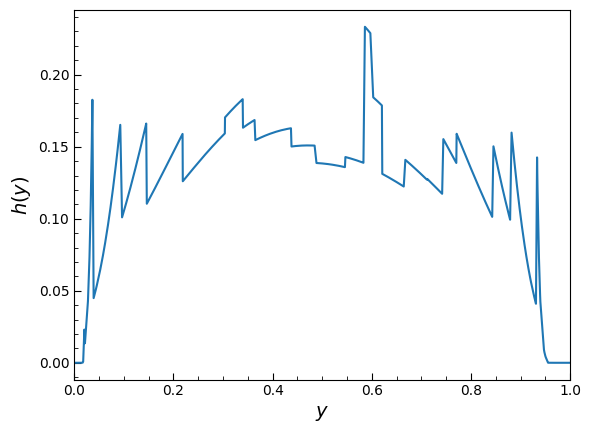

In [ ]:
print("Optimised parameters:", opt_params)
print("Optimised bin edges:", opt_bins)

plot_h(opt_params, opt_bins)

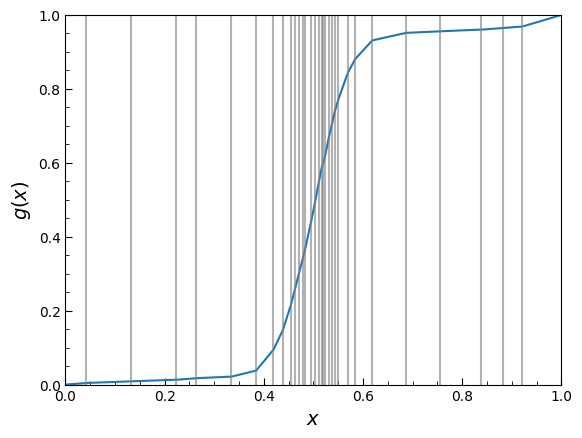

In [ ]:
plot_g(opt_params, opt_bins, display_bins=True)